# Réduction de dimensions

## Pourquoi réduire la dimensionnalité ?

Une **feature**, c'est une colonne. Un dataset avec **10 features** est facile à manipuler. Un dataset avec **10 000 features** (images, textes, logs bruts...) devient beaucoup plus compliqué. Au-delà d'un certain seuil, **ajouter des features dégrade les performances** plutôt que de les améliorer. C'est contre-intuitif — et c'est au cœur de ce notebook.

### Les trois problèmes d'avoir trop de features

1. **Temps d'apprentissage long.** Plus il y a de features, plus les calculs sont lourds. Un modèle qui prendrait 1 minute sur 10 features peut prendre des heures sur 10 000.
2. **Convergence difficile.** Beaucoup d'algorithmes ont du mal à « trouver » la bonne solution quand l'espace est trop grand. Le bruit noie le signal.
3. **Impossible à visualiser.** On sait dessiner des scatter plots en 2D ou 3D. Au-delà, on ne « voit » plus les données — on perd l'intuition visuelle qui est cruciale en EDA.

### La malédiction de la dimensionnalité

Ce phénomène a un nom : la **[curse of dimensionality](https://en.wikipedia.org/wiki/Curse_of_dimensionality)**. L'idée est simple : **en haute dimension, les données deviennent « clairsemées » de manière dramatique**, même si on en a beaucoup.

> **L'analogie à garder en tête :** imagine qu'on te demande de remplir un petit cube de 1 m × 1 m × 1 m avec des boules distantes de 10 cm. Il t'en faut environ 1000. Maintenant, on te demande de faire la même chose dans un hypercube en 4 dimensions. Puis en 10. Puis en 100. Le nombre de boules explose **exponentiellement** — en 10 dimensions, il t'en faut déjà $10^{10}$ = **10 milliards**.
>
> **Conséquence en ML :** au lieu d'être entourée de voisins proches (ce qui est le principe de base du machine learning — *« les points qui se ressemblent ont tendance à avoir la même étiquette »*), une donnée se retrouve **loin de tout le monde**. La notion même de « voisinage » perd son sens. KNN, K-Means, SVM... tous ces algorithmes basés sur la distance commencent à patiner.

### Le calcul qui fait peur

Si on veut avoir des points espacés de 0,01 (= $10^{-2}$) dans un hypercube de côté 1 :

| Dimension | Nombre de points nécessaires |
|:---:|:---:|
| 1 (segment) | $10^2$ = 100 |
| 2 (carré) | $10^4$ = 10 000 |
| 3 (cube) | $10^6$ = 1 million |
| 10 | $10^{20}$ |
| 100 | $10^{200}$ (plus que d'atomes dans l'univers) |

**Conséquence pratique :** une nouvelle donnée risque de se trouver très loin des autres → difficile à classifier → **comme si on avait un dataset insuffisant**, même avec des millions d'exemples.

### Le phénomène de Hughes

**La performance d'un classifieur en fonction du nombre de features** suit une courbe en cloche, connue sous le nom de **phénomène de Hughes** :

- **Peu de features** → le modèle sous-apprend (pas assez d'information).
- **Nombre optimal** → le modèle apprend le signal.
- **Trop de features** → la malédiction de la dimensionnalité frappe : le modèle apprend du bruit, sa performance **dégringole**.

![Optimal number of features](https://cdn.builtin.com/sites/www.builtin.com/files/styles/ckeditor_optimize/public/inline-images/national/classifier%2520performance%2520dimensionality.png)

> **🎯 Conclusion :** plus n'est pas toujours mieux. Parfois, **supprimer des features améliore les performances** — en éliminant du bruit, en simplifiant le problème, en rapprochant les données les unes des autres. C'est ce que fait la **réduction de dimensions**.

## Le plan de ce notebook

1. **Identifier les features inutiles** (illustration sur MNIST avec `feature_importances_`).
2. **PCA (Principal Component Analysis)** — la technique reine de réduction de dimensions.
3. **Mesurer l'impact** de la PCA sur la performance d'un modèle.
4. **Manifold learning** — pour les cas où la PCA ne suffit pas.

## Features « inutiles »

**Prenons un exemple visuel.** Les images MNIST (chiffres manuscrits) sont des matrices 28×28 = **784 pixels**. Mais est-ce que les 784 pixels sont **tous utiles** pour reconnaître un chiffre ?

**Intuition rapide :** les pixels aux **coins** et sur les **bords** sont presque toujours noirs (vides), quelle que soit l'image. Ils n'apportent **aucune information** pour distinguer un 3 d'un 8. Seuls les pixels du **centre** contiennent vraiment le signal.

> **Le principe général :** dans de nombreux datasets, beaucoup de features apportent **peu ou pas d'information**. Certaines sont constantes, d'autres redondantes, d'autres purement bruit. Les identifier et les supprimer **améliore** typiquement à la fois la **vitesse** et la **performance** du modèle.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style('whitegrid')

In [2]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, parser="auto")
X = mnist.data.values
y = mnist.target.astype(np.uint8)

In [3]:
# mnist_csv = pd.read_csv("../../data/mnist.csv")
# X = mnist_csv.drop("class", axis=1).values
# y = mnist_csv["class"]

In [4]:
def display_digits(X):
    plt.figure(figsize=(10,10))
    for i in range(25):
        plt.subplot(5, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        digit = X[i].reshape(28, 28)
        plt.imshow(digit, cmap=plt.cm.binary)
    plt.show()

In [5]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

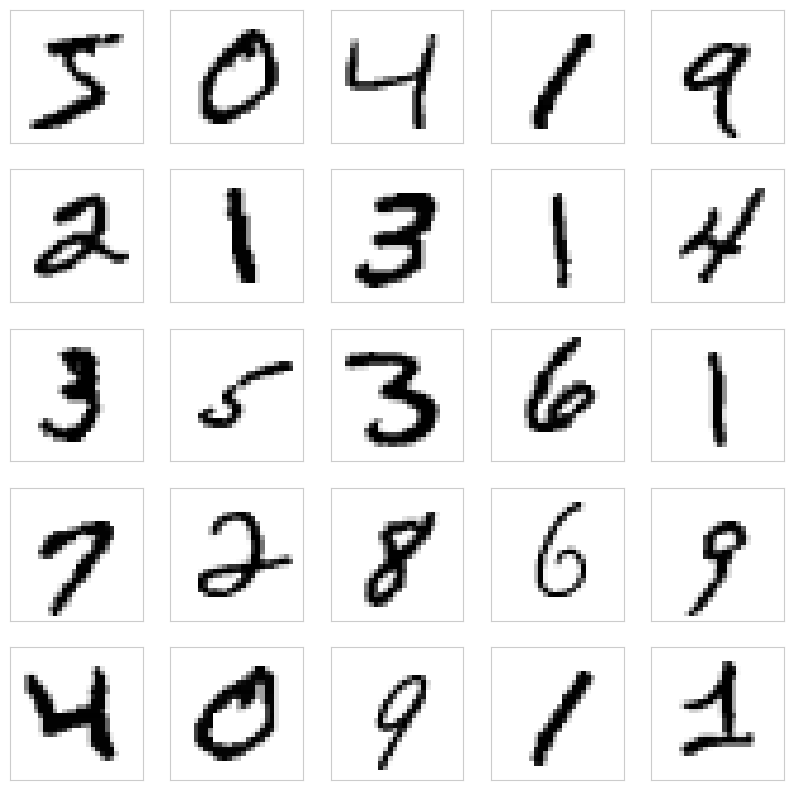

In [6]:
display_digits(X)

**Intuition confirmée visuellement** : les pixels périphériques sont presque toujours noirs et n'apportent rien à la classification.

### Quantifier l'importance avec `feature_importances_`

**On va le confirmer algorithmiquement** en utilisant un `RandomForestClassifier`, qui fournit gratuitement un **ordre d'importance** des features via son attribut `feature_importances_`.

> **Comment ça marche ?** Pour chaque feature, le Random Forest mesure à quel point elle est utilisée par les arbres pour séparer les classes. Une feature utilisée souvent et haut dans les arbres → importance élevée. Une feature jamais utilisée (ou rarement) → importance faible.
>
> **Le résultat est un vecteur** qui, pour MNIST, se transforme en une **carte thermique 28×28** montrant quels pixels comptent vraiment. On va voir qu'elle ressemble à une « auréole » concentrée au centre — exactement là où les chiffres sont dessinés.

In [7]:
from sklearn.ensemble import RandomForestClassifier

rnd_clf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rnd_clf.fit(X, y)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [8]:
def plot_digit(data, yticklabels):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap = "hot", interpolation="nearest")
    plt.axis("off")
    cbar = plt.colorbar(
        ticks=[rnd_clf.feature_importances_.min(), rnd_clf.feature_importances_.max()]
    )
    cbar.ax.set_yticklabels(yticklabels)

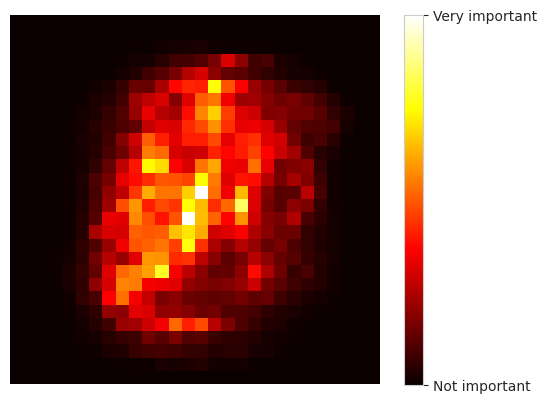

In [9]:
plot_digit(rnd_clf.feature_importances_, ['Not important', 'Very important'])

## PCA (Principal Component Analysis)

### L'idée intuitive

La PCA est l'**outil le plus célèbre et le plus utilisé** de réduction de dimensions. Son principe est une **transformation des axes** des données :

- On cherche de **nouveaux axes** (appelés **composantes principales**) qui capturent **le maximum de variance** possible dans les données.
- Le **premier axe** est celui sur lequel les données sont les plus étalées.
- Le **deuxième** est perpendiculaire au premier et capture le maximum de variance restante.
- Etc.
- On **conserve les $k$ premiers axes** (les plus informatifs) et on **supprime les autres**.

> **L'analogie à garder en tête :** imagine un nuage de points 3D qui ressemble en fait à une « crêpe » aplatie — tous les points sont presque dans un même plan, mais ce plan n'est pas aligné avec les axes X, Y, Z. La PCA **fait pivoter le repère** pour aligner le premier axe avec la direction la plus étalée du nuage, le deuxième avec la deuxième plus étalée, et le troisième (perpendiculaire aux deux autres) capture ce qui reste — très peu, puisque les points sont quasi-plans. On peut alors **ignorer le troisième axe** et passer de 3D à 2D **sans presque rien perdre**.

![PCA](https://upload.wikimedia.org/wikipedia/commons/f/f5/GaussianScatterPCA.svg)

### Un peu de mathématiques (pour les curieux)

Les composantes principales sont les **vecteurs propres** de la matrice de **covariance** des données — classés par **valeurs propres décroissantes** (la valeur propre d'un vecteur = quantité de variance capturée par cet axe).

**En langage courant :** on trouve les directions les plus « gonflées » du nuage, et on les ordonne de la plus gonflée à la moins gonflée. On garde les $k$ premières et on ignore les autres.

### Ce que permet la PCA

1. **Compression** : passer de 784 dimensions à 64 ou même 16, tout en gardant l'essentiel de l'information.
2. **Visualisation** : projeter en 2D ou 3D pour voir la structure du dataset (très utile pour l'EDA).
3. **Débruitage** : les composantes à faible variance capturent souvent du bruit. Les supprimer nettoie les données.
4. **Accélération** : un modèle entraîné sur 16 dimensions est **beaucoup plus rapide** qu'un modèle sur 784.

### La PCA inverse — reconstituer les données

**Propriété intéressante :** la transformation PCA est **réversible**. Si on garde **tous** les axes, `pca.inverse_transform()` restaure parfaitement les données originales. Si on n'en garde qu'une partie, la reconstitution n'est que **partielle** — mais visuellement, ça reste reconnaissable si on a gardé assez de composantes.

On va utiliser cette propriété pour **voir** à quoi ressemblent les chiffres MNIST **après** compression à 256, 64 et 16 dimensions, en reconstituant les images à partir de ces représentations compressées. Plus on compresse fort, plus les détails disparaissent — mais la structure globale persiste étonnamment longtemps.

### ⚠️ Pièges à connaître

- **La PCA est sensible à l'échelle** : une feature en [0, 1000] va dominer une feature en [0, 1] dans le calcul de variance. **Toujours normaliser (`StandardScaler`) avant une PCA** sur des features d'échelles différentes.
- **La PCA est linéaire** : elle ne capture que des relations linéaires entre variables. Pour des structures non linéaires (des spirales, des courbes), utiliser **Kernel PCA**, **t-SNE** ou **UMAP**.
- **Les composantes principales ne sont pas interprétables** : ce ne sont pas des features métier mais des combinaisons linéaires de features originales. On perd l'interprétabilité.

In [10]:
from sklearn.decomposition import PCA

def pca_recovered(n_components, X):
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X)
    X_recovered = pca.inverse_transform(X_reduced)
    return X_recovered

n_components=784


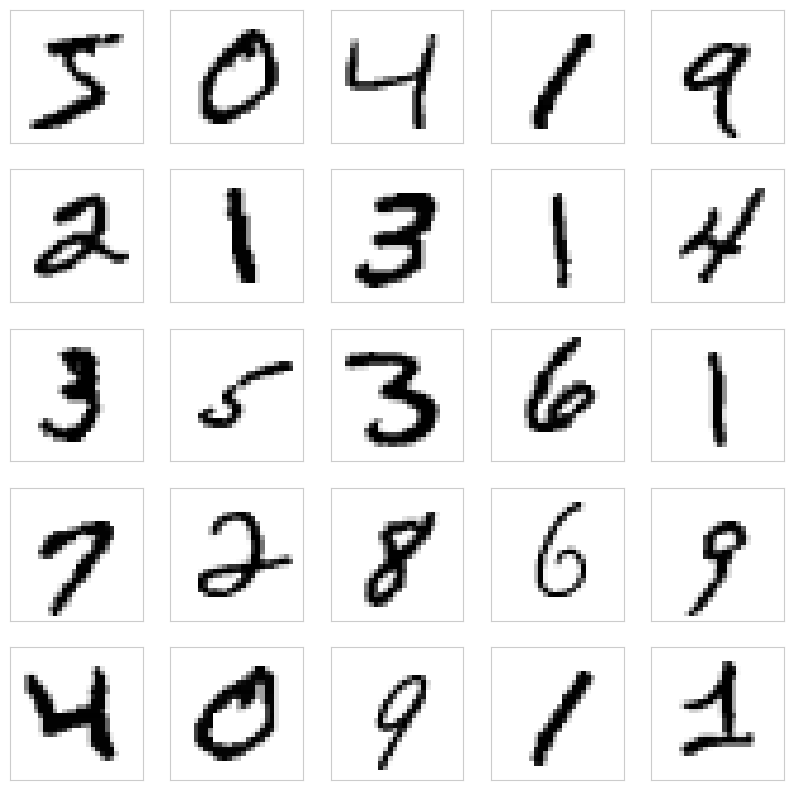

n_components=256


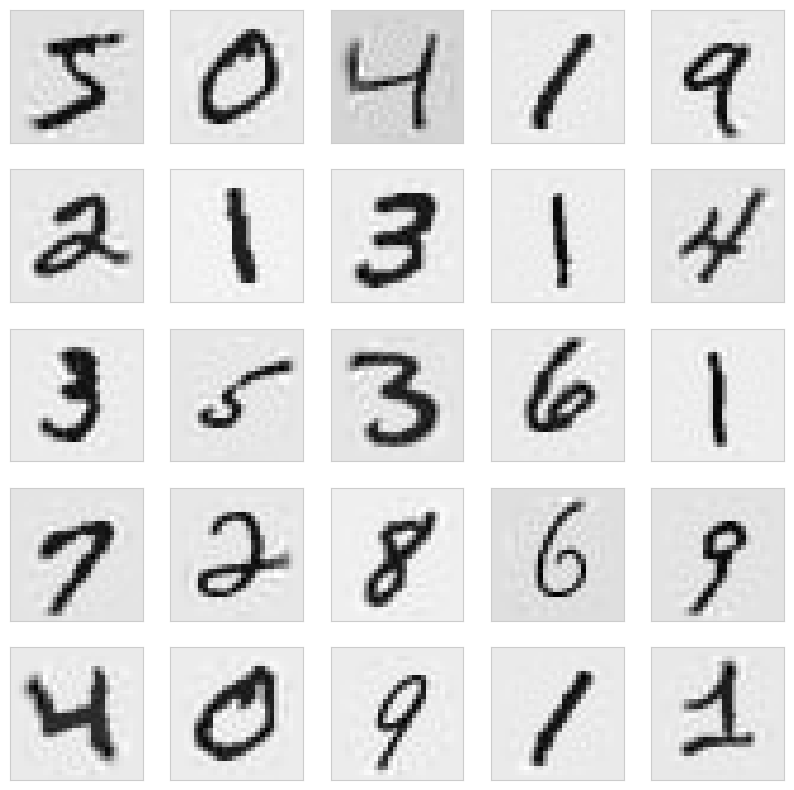

n_components=64


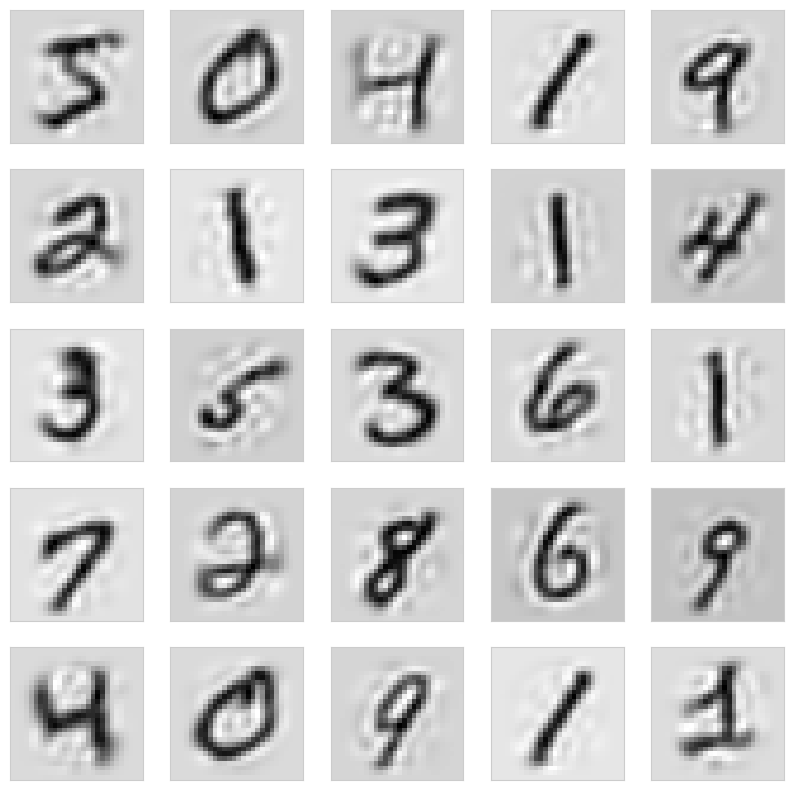

n_components=16


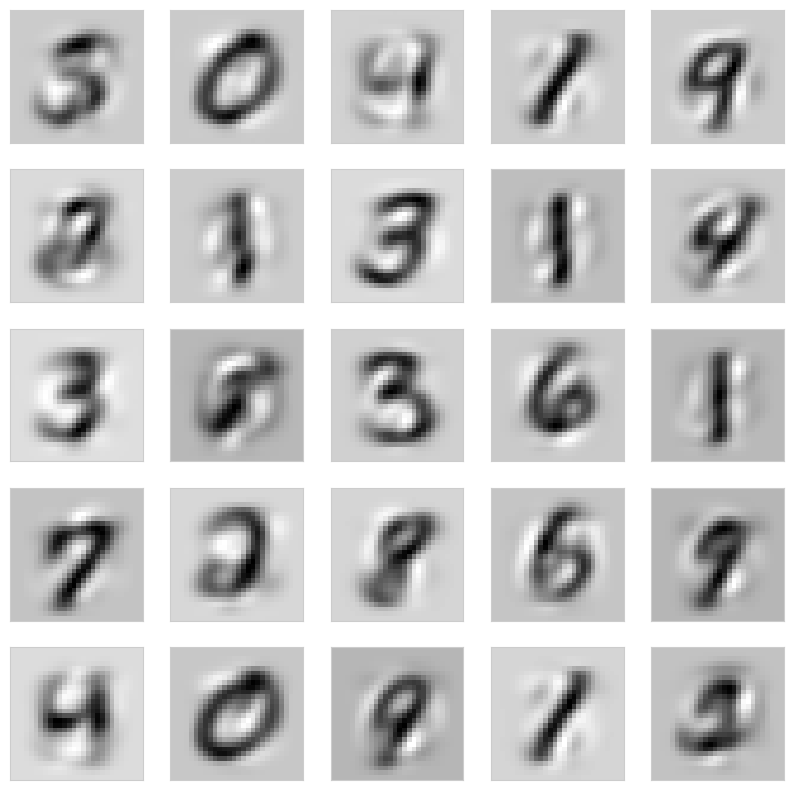

In [11]:
for n_components in [28*28, 256, 64, 16]:
    print(f"n_components={n_components}")
    X_recovered = pca_recovered(n_components, X)
    display_digits(X_recovered)

### Effet de la PCA sur l'apprentissage

**Passons à la mesure concrète.** On va entraîner un `RandomForestClassifier` sur MNIST **avec** et **sans** PCA, et comparer les scores en cross-validation.

> **Hypothèse à tester :** la PCA **n'est pas gratuite** — elle compresse l'information, on s'attend donc à une **petite perte de performance**. Mais si cette perte est faible (quelques pourcents), et que le gain en **vitesse** est grand (10× plus rapide), c'est souvent un très bon compromis en pratique.

In [12]:
# Les premières 60000 images -> train set
# Les dernières 10000 images -> test set

X_train, X_test, y_train, y_test = X[:60_000], X[60_000:], y[:60_000], y[60_000:]

#### Sans PCA — le baseline

**On entraîne d'abord sur les 784 pixels bruts.** C'est notre référence : le score à battre (ou à approcher).

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [14]:
cross_val_score(
    RandomForestClassifier(max_depth=20, random_state=2, n_jobs=-1),
    X_train, y_train, cv=3, scoring="accuracy", n_jobs=-1
)

array([0.96405, 0.963  , 0.96495])

#### Avec PCA — compression à 256, 64 et 16 dimensions

**On compare maintenant** trois niveaux de compression. Combien de composantes peut-on supprimer avant que le modèle ne s'effondre ?

> **À quoi s'attendre ?** Une légère dégradation en passant de 784 → 256, un peu plus forte en allant à 64, et significative à 16. L'objectif est de **situer le bon compromis** pour ce cas d'usage.

In [15]:
pca = PCA(n_components=256)
X_reduced = pca.fit_transform(X_train)
cross_val_score(
    RandomForestClassifier(max_depth=20, random_state=2, n_jobs=-1),
    X_reduced, y_train, cv=3, scoring="accuracy", n_jobs=-1
)

array([0.9355 , 0.9317 , 0.93815])

In [16]:
pca = PCA(n_components=64)
X_reduced = pca.fit_transform(X_train)
cross_val_score(
    RandomForestClassifier(max_depth=20, random_state=2, n_jobs=-1),
    X_reduced, y_train, cv=3, scoring="accuracy", n_jobs=-1
)

array([0.94665, 0.94205, 0.9486 ])

In [17]:
pca = PCA(n_components=16)
X_reduced = pca.fit_transform(X_train)
cross_val_score(
    RandomForestClassifier(max_depth=20, random_state=2, n_jobs=-1),
    X_reduced, y_train, cv=3, scoring="accuracy", n_jobs=-1
)

array([0.93515, 0.93425, 0.93565])

**Observation :** on constate une **légère diminution de la justesse** à mesure qu'on compresse, mais avec des résultats **étonnamment bons** — **même avec seulement 16 dimensions** (au lieu de 784 !).

> **🎯 Ce que ça signifie concrètement :**
>
> - On peut **diviser par ~50 le nombre de features** tout en gardant un modèle fonctionnel.
> - L'entraînement devient **beaucoup plus rapide** (des minutes au lieu d'heures sur de gros datasets).
> - Le stockage et la mémoire nécessaires sont **divisés d'autant**.
>
> **Quand ça paye vraiment :** sur des datasets **énormes** (images haute résolution, textes vectorisés...) où chaque dimension coûte cher en temps et en mémoire, une PCA intelligente peut faire la différence entre *« ça ne tient pas sur ma machine »* et *« ça tourne en quelques minutes »*.

## Utiliser des algorithmes pour **sélectionner** les features

La PCA **crée de nouvelles features** (combinaisons linéaires des originales). Une approche alternative est de **sélectionner** directement les meilleures features parmi celles qu'on a déjà.

### Utiliser `feature_importances_`

Comme on l'a vu plus haut, certains algorithmes (Random Forest, Gradient Boosting, XGBoost, LightGBM) fournissent naturellement une **mesure d'importance** de chaque feature. On peut :

1. Entraîner un premier modèle sur toutes les features.
2. Trier les features par importance décroissante.
3. Ne garder que les $k$ meilleures (par exemple les 20% qui représentent 80% de l'importance — règle de Pareto).
4. Réentraîner un modèle final sur ce sous-ensemble.

**Avantage par rapport à la PCA :** on garde les **features d'origine**, donc on préserve l'interprétabilité. Une analyse *« les 5 features les plus prédictives sont X, Y, Z, ... »* reste possible.

### Utiliser la régularisation Lasso

La **régularisation $L_1$ (Lasso)** a une propriété remarquable : elle **met exactement à 0** les coefficients des features les moins utiles. À la fin de l'entraînement, les features gardées sont celles dont le coefficient n'est pas à 0 — **Lasso fait de la sélection automatique**.

```python
from sklearn.linear_model import LassoCV
lasso = LassoCV(cv=5).fit(X_train, y_train)
# Features sélectionnées (coefficient non nul)
selected = np.where(lasso.coef_ != 0)[0]
```

### Autres outils scikit-learn

- **`SelectKBest`** — sélectionne les $k$ features ayant le meilleur score d'un test statistique (chi², F-test, mutual info).
- **`RFE` (*Recursive Feature Elimination*)** — élimine une feature à la fois et mesure l'impact.
- **`SelectFromModel`** — utilise un modèle (Lasso, RandomForest...) pour choisir les features en fonction de leur importance.

## Manifold learning — quand la PCA ne suffit pas

### L'idée du « manifold » (ou *variété*)

**Une variété de dimension $d$ dans un espace de dimension $n$** ($d < n$) est une structure qui, localement, ressemble à un espace $d$-dimensionnel, même si elle « vit » dans un espace de dimension plus grande.

> **L'analogie à garder en tête :** imagine une **feuille de papier roulée en boule** dans une pièce. La pièce est 3D, mais la feuille elle-même est 2D — c'est une variété de dimension 2 plongée dans un espace de dimension 3. Si on la « déroule » mentalement, on retrouve une feuille plate. **Le manifold learning, c'est apprendre à dérouler cette feuille** sans la déchirer.

### L'hypothèse du manifold

**L'hypothèse centrale :** *« les données de grande dimension vivent souvent, en pratique, sur une variété de dimension bien plus faible »*.

Par exemple, les **28×28 = 784 pixels** de MNIST forment théoriquement un espace à 784 dimensions, mais en pratique, les chiffres manuscrits occupent un **sous-espace beaucoup plus petit** (peut-être 10 ou 20 dimensions) — celui des « formes qui ressemblent à des chiffres ». Tout le reste des 784 dimensions est inutilisé.

**Ce n'est pas toujours vrai** — parfois les données sont véritablement éparpillées dans l'espace complet. Mais quand c'est vrai, ça ouvre la porte à des techniques de réduction bien plus puissantes que la PCA linéaire.

### Les principales techniques

| Technique | Usage typique | Force | Limitation |
|---|---|---|---|
| **Kernel PCA** | Généraliste, variétés simples | Gère les relations non linéaires | Nécessite de choisir un kernel |
| **t-SNE** | **Visualisation 2D/3D** d'embeddings | Excellent pour voir les clusters | Lent, stochastique, pas inversible |
| **UMAP** | Visualisation + réduction | Plus rapide que t-SNE, préserve mieux la structure globale | Hyperparamètres délicats |
| **Isomap** | Variétés courbes | Préserve les distances géodésiques | Sensible au bruit, lent |
| **LLE** (*Locally Linear Embedding*) | Variétés lisses | Bonne préservation locale | Sensible aux paramètres |

### Quand utiliser chaque outil

- **Pour compresser et accélérer un modèle** → **PCA** en premier choix. Simple, rapide, testée.
- **Pour visualiser un dataset en 2D** → **UMAP** (ou **t-SNE** si on cible la bonne séparation visuelle des clusters).
- **Pour explorer les patterns cachés** dans un dataset complexe (texte embeddings, images) → **UMAP** ou **t-SNE**.
- **Pour un dataset avec des relations vraiment non linéaires** → **Kernel PCA** ou **Isomap**.

## 🎯 Pour résumer — réduction de dimensions en pratique

### Quand l'utiliser

- ✅ **Dataset à très grandes dimensions** : images, textes vectorisés, séries temporelles longues, logs bruts.
- ✅ **Modèles sensibles à la dimensionnalité** : KNN, K-Means, SVM, régressions régularisées.
- ✅ **Visualisation** d'un dataset en 2D/3D pour l'EDA.
- ✅ **Accélération** d'entraînement quand le temps compte (itérations rapides en exploration).
- ✅ **Suppression de bruit** : les composantes à faible variance capturent souvent du bruit.

### Quand ne pas s'en occuper

- ❌ **Dataset à faible dimensionnalité** (< 50 features) → rarement utile. Le coût de la perte d'interprétabilité ne se justifie pas.
- ❌ **Modèles à arbres** (Random Forest, XGBoost) sur dataset modéré → ils gèrent bien la haute dimension et perdent souvent en performance après PCA.
- ❌ **Interprétabilité critique** → la PCA crée des features non interprétables. Préférer la **sélection de features** (Lasso, importance de RF).

### Les outils à connaître

| Outil | Type | Usage |
|---|---|---|
| **`PCA`** | Linéaire | Référence par défaut. Simple, rapide, explicable. |
| **`TruncatedSVD`** | Linéaire | PCA pour matrices creuses (textes TF-IDF par exemple). |
| **`KernelPCA`** | Non linéaire | Quand la PCA linéaire ne capture pas la structure. |
| **`t-SNE`** | Non linéaire | Visualisation 2D/3D. Excellent pour voir les clusters. |
| **`UMAP`** | Non linéaire | Visualisation moderne. Plus rapide que t-SNE. |
| **`Isomap`, `LLE`** | Non linéaire | Variantes pour structures spécifiques (courbes, surfaces). |
| **`SelectKBest`, `RFE`** | Sélection | Garder les features d'origine (pas de transformation). |
| **Lasso / RandomForest importance** | Sélection | Méthodes simples et efficaces sur données tabulaires. |

### Les bonnes pratiques

- ✅ **Toujours normaliser avant PCA** (`StandardScaler`) quand les features sont d'échelles différentes.
- ✅ **Choisir le nombre de composantes** en regardant la **courbe de variance expliquée** : `pca.explained_variance_ratio_.cumsum()`. Un coude naturel indique souvent le bon choix.
- ✅ **Fitter sur le train uniquement**, appliquer au test — toujours la règle d'or anti-leakage.
- ✅ **Mesurer l'impact** en cross-validation avant/après — s'assurer que la compression vaut le coup.
- ✅ **Pour la visualisation**, utiliser PCA d'abord pour débruiter (par exemple vers 50 dimensions), **puis** t-SNE / UMAP pour la projection 2D finale. C'est le combo standard en pratique.

### Les pièges à éviter

- ⚠️ **Ne pas normaliser avant PCA** → une feature dominante écrase tout. Erreur classique.
- ⚠️ **Interpréter les composantes principales comme des concepts métier** → ce sont des combinaisons mathématiques, pas des réalités physiques. Décrire `PC1` en mots est risqué.
- ⚠️ **Appliquer t-SNE avec différents paramètres et comparer** → chaque run peut donner des visualisations très différentes (t-SNE est stochastique). Toujours fixer `random_state` et essayer plusieurs `perplexity`.
- ⚠️ **Utiliser la réduction de dimensions comme baguette magique** → ce n'est pas un remède universel. Parfois, elle fait perdre plus qu'elle ne gagne. Toujours **mesurer**.

### Le mot de la fin

> **La réduction de dimensions est un outil d'optimisation, pas de magie.** Dans 80% des cas tabulaires, tu peux t'en passer — les modèles modernes (XGBoost, LightGBM) gèrent bien la haute dimension. Mais pour les cas où elle est vraiment utile (très grandes dimensions, visualisation, modèles sensibles), la PCA reste **la première à essayer** pour sa simplicité et sa robustesse. Les techniques non linéaires (UMAP, t-SNE) sont là pour les cas où la PCA ne capte pas la structure — et pour l'exploration visuelle, où elles brillent.